In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [9]:
map_ipeds_name = {
    "110662": "University of California-Los Angeles",
    "200280": "University of North Dakota",
    "231174": "University of Vermont",
    # Add more ipeds_id:name pairs here as needed
}

In [2]:
chunk_files = [
    "../ContextualEmbeddings/outputs/chunks/selected_universities_course_level_embeddings_chunk_1.pkl",
    "../ContextualEmbeddings/outputs/chunks/selected_universities_course_level_embeddings_chunk_2.pkl",
    "../ContextualEmbeddings/outputs/chunks/selected_universities_course_level_embeddings_chunk_3_part1.pkl",
    "../ContextualEmbeddings/outputs/chunks/selected_universities_course_level_embeddings_chunk_3_part2.pkl",
    "../ContextualEmbeddings/outputs/chunks/selected_universities_course_level_embeddings_chunk_4.pkl",
    "../ContextualEmbeddings/outputs/chunks/selected_universities_course_level_embeddings_chunk_5.pkl",
    "../ContextualEmbeddings/outputs/chunks/selected_universities_course_level_embeddings_chunk_6.pkl",
    "../ContextualEmbeddings/outputs/chunks/selected_universities_course_level_embeddings_chunk_7.pkl",
    "../ContextualEmbeddings/outputs/chunks/selected_universities_course_level_embeddings_chunk_8.pkl",
]

chunks = []
for file in chunk_files:
    print(f"Loading {file.split('/')[-1]}...")
    chunks.append(pd.read_pickle(file))

# Concatenate all chunks
new_embeddings = pd.concat(chunks, ignore_index=True)

print(f"\nTotal rows: {len(new_embeddings)}")
print(f"Shape: {new_embeddings.shape}")

Loading selected_universities_course_level_embeddings_chunk_1.pkl...
Loading selected_universities_course_level_embeddings_chunk_2.pkl...
Loading selected_universities_course_level_embeddings_chunk_3_part1.pkl...
Loading selected_universities_course_level_embeddings_chunk_3_part2.pkl...
Loading selected_universities_course_level_embeddings_chunk_4.pkl...
Loading selected_universities_course_level_embeddings_chunk_5.pkl...
Loading selected_universities_course_level_embeddings_chunk_6.pkl...
Loading selected_universities_course_level_embeddings_chunk_7.pkl...
Loading selected_universities_course_level_embeddings_chunk_8.pkl...

Total rows: 796202
Shape: (796202, 55)


In [39]:
AI_keywords = [
    'Turing',
    'Turing machine',
    'Logic theorist',
    'Evolutionary computation',
    'Computational',
    'Computer vision',
    'Thinking Machines',
    'Symbolic reasoning',
    'Cellular Automata',
    'Cognitive revolution',
    'AI',
    'Artificial Intelligence',
    'Computational Intelligence',
    'Algorithm',
    'Machine Learning',
    'ML',
    'Supervised learning',
    'Unsupervised learning',
    'Semi-supervised learning',
    'Reinforcement learning',
    'Deep learning',
    'Neural networks',
    'Bayesian Networks',
    'Evolutionary Computation',
    'Natural language processing',
    'Data Science',
    'Computational Social Science',
    'Network Science',
    'Large Language Models'
]


In [38]:
# Melt to long format
# Instead of having one column per AI keyword, we have one row per (course, AI keyword) pair
df_overall = new_embeddings.melt(
    id_vars=['ipeds_id', 'cat_type', 'start_yr', 'end_yr', 
             'Department', 'DepartmentCleaned', 'Number', 'Title', 
             'Description', 'decade', 'quinquennium',
             'id_department_course', 'id_catalog'],  # <- Add these two columns here
    value_vars=AI_keywords,
    var_name='AI_word',
    value_name='cos'
)

# Create start_end_year column for plotting
df_overall['start_end_year'] = df_overall['start_yr'].astype(str) + '_' + df_overall['end_yr'].astype(str)

# Find the index of max similarity for each course
idx_max = df_overall.groupby(
    ['ipeds_id', 'cat_type', 'start_yr', 'end_yr', 'start_end_year',
     'Department', 'DepartmentCleaned', 'Number', 'Title', 'Description']
)['cos'].idxmax()

# Use those indices to get both max value and keyword
df_course_level = df_overall.loc[idx_max, [
    'ipeds_id', 'cat_type', 'start_yr', 'end_yr', 'start_end_year',
    'Department', 'DepartmentCleaned', 'Number', 'Title', 'Description',
    'cos', 'AI_word', 'id_department_course', 'id_catalog'
]].rename(columns={'cos': 'max_cos_similarity', 'AI_word': 'best_matching_keyword'}).reset_index(drop=True)

In [59]:
df_course_level.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690501 entries, 0 to 690500
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ipeds_id               690501 non-null  object 
 1   cat_type               690501 non-null  object 
 2   start_yr               690501 non-null  int64  
 3   end_yr                 690501 non-null  int64  
 4   start_end_year         690501 non-null  object 
 5   Department             690501 non-null  object 
 6   DepartmentCleaned      690501 non-null  object 
 7   Number                 690501 non-null  object 
 8   Title                  690501 non-null  object 
 9   Description            690501 non-null  object 
 10  max_cos_similarity     690501 non-null  float32
 11  best_matching_keyword  690501 non-null  object 
 12  id_department_course   690501 non-null  object 
 13  id_catalog             690501 non-null  object 
dtypes: float32(1), int64(2), object(11)


In [13]:
df_course_level.to_pickle("../ContextualEmbeddings/outputs/selected_universities_course_level_embeddings.pkl")

In [90]:
# Count TOTAL courses per university per catalog year
df_totals = df_course_level.groupby(
    ['ipeds_id', 'cat_type', 'start_yr', 'end_yr', 'start_end_year']
).size().reset_index(name='num_total_courses')

# Filter to AI courses above threshold
ai_courses = df_course_level[df_course_level['max_cos_similarity'] >= 0.43]

# Count AI courses per university per catalog year
df_timeseries = ai_courses.groupby(
    ['ipeds_id', 'cat_type', 'start_yr', 'end_yr', 'start_end_year']
).size().reset_index(name='num_ai_courses')

# Merge to get both counts
df_timeseries = df_timeseries.merge(df_totals, on=['ipeds_id', 'cat_type', 'start_yr', 'end_yr', 'start_end_year'], how='right')
df_timeseries['num_ai_courses'] = df_timeseries['num_ai_courses'].fillna(0)

# Sort by start_yr for proper time series plotting
df_timeseries = df_timeseries.sort_values('start_yr')

# print(f"Time series data shape: {df_timeseries.shape}")
# print(df_timeseries.head(10))

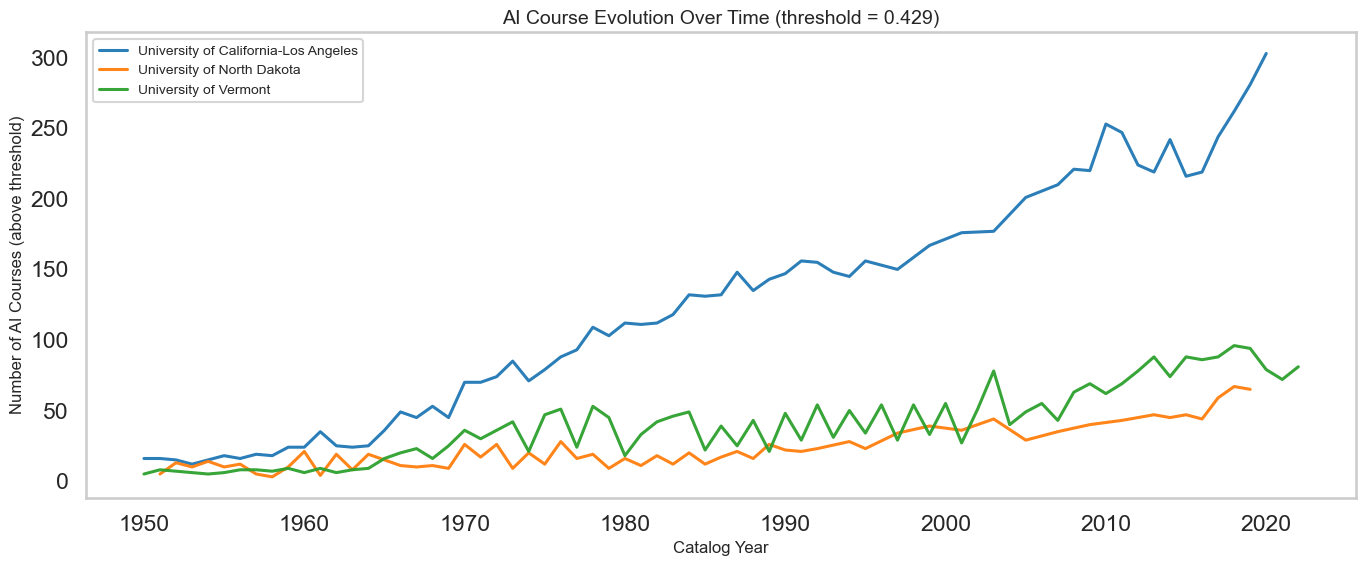

In [89]:
threshold = 0.4290
sns.set_style('whitegrid')
sns.set_context('talk', rc={'axes.titlesize':14, 'axes.labelsize':12, 'legend.fontsize':10})
fig, ax = plt.subplots(figsize=(14, 6))

# Aggregate across catalog types
df_agg = df_timeseries.groupby(['ipeds_id', 'start_yr'], as_index=False)['num_ai_courses'].sum()
df_agg = df_agg[df_agg['start_yr'] >= 1950]

# Color palette assigned per university
ipeds_list = list(df_agg['ipeds_id'].unique())
palette = sns.color_palette('tab10', n_colors=max(3, len(ipeds_list)))
colors_by_ipeds = {ipeds: palette[i % len(palette)] for i, ipeds in enumerate(ipeds_list)}

for ipeds in ipeds_list:
    data = df_agg[df_agg['ipeds_id'] == ipeds].sort_values('start_yr')
    if data.empty:
        continue
    
    uni_color = colors_by_ipeds[ipeds]
    label = map_ipeds_name.get(ipeds, ipeds)
    
    ax.plot(data['start_yr'], data['num_ai_courses'], 
            color=uni_color, linestyle='-',
            linewidth=2.2, marker='', markersize=4, 
            markeredgewidth=0.6, markeredgecolor='white',
            label=label, alpha=0.95)

ax.set_xlabel('Catalog Year')
ax.set_ylabel('Number of AI Courses (above threshold)')
ax.set_title(f'AI Course Evolution Over Time (threshold = {threshold})')
ax.legend(loc='best', frameon=True)
ax.grid(False)

plt.tight_layout()
import os
os.makedirs(os.path.join('..', 'figures'), exist_ok=True)
plt.savefig('../figures/updated_timeseries_ai_courses_totals.png', dpi=300, bbox_inches='tight')
plt.show()

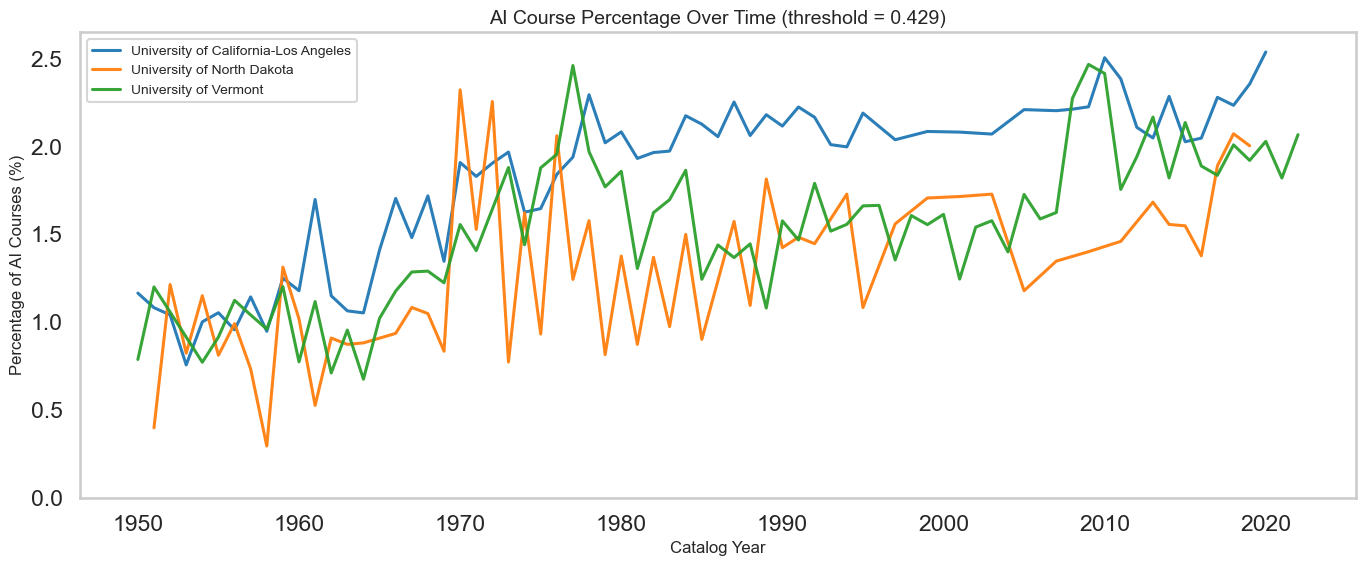

In [88]:
threshold = 0.4290
sns.set_style('whitegrid')
sns.set_context('talk', rc={'axes.titlesize':14, 'axes.labelsize':12, 'legend.fontsize':10})
fig, ax = plt.subplots(figsize=(14, 6))

# Aggregate across catalog types - sum both AI courses and total courses
df_agg = df_timeseries.groupby(['ipeds_id', 'start_yr'], as_index=False).agg({
    'num_ai_courses': 'sum',
    'num_total_courses': 'sum'
})

# Calculate percentage
df_agg['pct_ai_courses'] = (df_agg['num_ai_courses'] / df_agg['num_total_courses']) * 100

# Filter to 1950 onwards
df_agg = df_agg[df_agg['start_yr'] >= 1950]

# Color palette assigned per university
ipeds_list = list(df_agg['ipeds_id'].unique())
palette = sns.color_palette('tab10', n_colors=max(3, len(ipeds_list)))
colors_by_ipeds = {ipeds: palette[i % len(palette)] for i, ipeds in enumerate(ipeds_list)}

for ipeds in ipeds_list:
    data = df_agg[df_agg['ipeds_id'] == ipeds].sort_values('start_yr')
    if data.empty:
        continue
    
    uni_color = colors_by_ipeds[ipeds]
    label = map_ipeds_name.get(ipeds, ipeds)
    
    ax.plot(data['start_yr'], data['pct_ai_courses'], 
            color=uni_color, linestyle='-',
            linewidth=2.2, 
            label=label, alpha=0.95)

ax.set_xlabel('Catalog Year')
ax.set_ylabel('Percentage of AI Courses (%)')
ax.set_title(f'AI Course Percentage Over Time (threshold = {threshold})')
ax.set_ylim(0, None)  # Start y-axis at 0, auto-scale the max
ax.legend(loc='best', frameon=True)
ax.grid(False)

plt.tight_layout()
import os
os.makedirs(os.path.join('..', 'figures'), exist_ok=True)
plt.savefig('../figures/updated_timeseries_ai_courses_percentages.png', dpi=300, bbox_inches='tight')
plt.show()

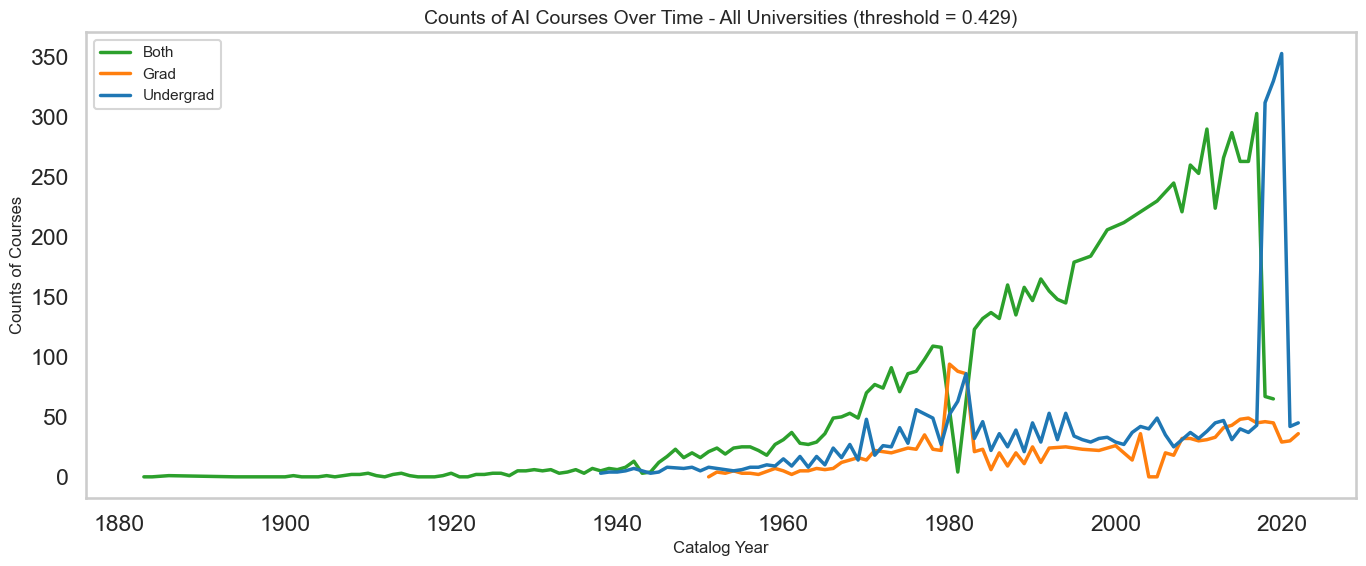

In [91]:
# Aggregate across all universities, grouping only by catalog type and year
df_plot = df_timeseries.groupby(['cat_type', 'start_yr']).agg({
    'num_ai_courses': 'sum'
}).reset_index()

# Use seaborn styling to match aesthetic
import seaborn as sns
sns.set_style('whitegrid')
sns.set_context('talk', rc={'axes.titlesize':14, 'axes.labelsize':12, 'legend.fontsize':11})
fig, ax = plt.subplots(figsize=(14, 6))

# Colors chosen to match the sample (blue, orange, green)
cat_type_styles = {
    'ug': {'linestyle': '-', 'color': '#1f77b4', 'label': 'Undergrad'},
    'gr': {'linestyle': '-', 'color': '#ff7f0e', 'label': 'Grad'},
    'both': {'linestyle': '-', 'color': '#2ca02c', 'label': 'Both'},
    # also accept verbose names
    'undergraduate': {'linestyle': '-', 'color': '#1f77b4', 'label': 'Undergrad'},
    'graduate': {'linestyle': '-', 'color': '#ff7f0e', 'label': 'Grad'},
}

# Plot each catalog type using seaborn's lineplot for nicer default aesthetics
for cat_type in df_plot['cat_type'].unique():
    data = df_plot[df_plot['cat_type'] == cat_type].sort_values('start_yr')
    style = cat_type_styles.get(cat_type, {'linestyle': '-', 'color': 'gray', 'label': cat_type})
    sns.lineplot(data=data, x='start_yr', y='num_ai_courses', ax=ax, 
                 marker='', linewidth=2.5, markersize=6, 
                 linestyle=style['linestyle'], color=style['color'], label=style['label'])

ax.set_xlabel('Catalog Year')
ax.set_ylabel('Counts of Courses')
ax.set_title(f'Counts of AI Courses Over Time - All Universities (threshold = {threshold})')
ax.legend(loc='best', fontsize=11)
ax.grid(False)

plt.tight_layout()
import os
os.makedirs(os.path.join('..', 'figures'), exist_ok=True)
plt.savefig('../figures/updated_timeseries_ai_courses_combined_totals.png', dpi=300, bbox_inches='tight')
plt.show()

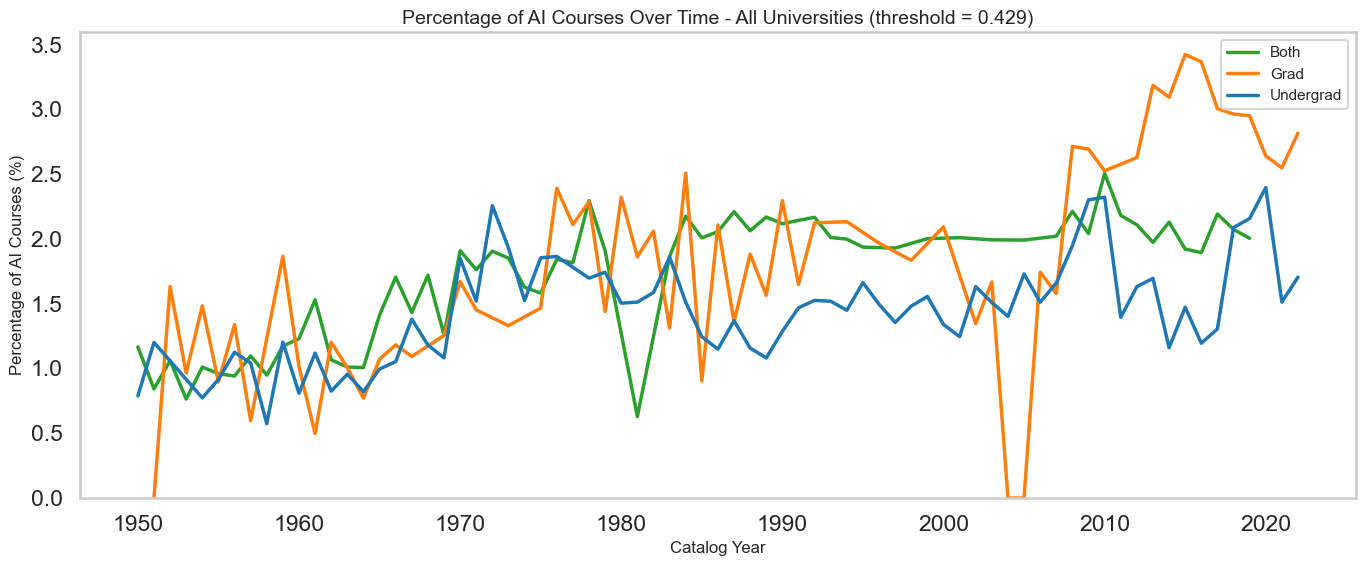

In [96]:
# Aggregate across all universities, grouping only by catalog type and year
df_plot = df_timeseries.groupby(['cat_type', 'start_yr']).agg({
    'num_ai_courses': 'sum',
    'num_total_courses': 'sum'
}).reset_index()

# Calculate percentage
df_plot['pct_ai_courses'] = (df_plot['num_ai_courses'] / df_plot['num_total_courses']) * 100

# Filter to 1950 onwards (optional)
df_plot = df_plot[df_plot['start_yr'] >= 1950]

# Use seaborn styling to match aesthetic
import seaborn as sns
sns.set_style('whitegrid')
sns.set_context('talk', rc={'axes.titlesize':14, 'axes.labelsize':12, 'legend.fontsize':11})
fig, ax = plt.subplots(figsize=(14, 6))

# Colors chosen to match the sample (blue, orange, green)
cat_type_styles = {
    'ug': {'linestyle': '-', 'color': '#1f77b4', 'label': 'Undergrad'},
    'gr': {'linestyle': '-', 'color': '#ff7f0e', 'label': 'Grad'},
    'both': {'linestyle': '-', 'color': '#2ca02c', 'label': 'Both'},
    # also accept verbose names
    'undergraduate': {'linestyle': '-', 'color': '#1f77b4', 'label': 'Undergrad'},
    'graduate': {'linestyle': '-', 'color': '#ff7f0e', 'label': 'Grad'},
}

# Plot each catalog type using seaborn's lineplot for nicer default aesthetics
for cat_type in df_plot['cat_type'].unique():
    data = df_plot[df_plot['cat_type'] == cat_type].sort_values('start_yr')
    style = cat_type_styles.get(cat_type, {'linestyle': '-', 'color': 'gray', 'label': cat_type})
    sns.lineplot(data=data, x='start_yr', y='pct_ai_courses', ax=ax, 
                 marker='', linewidth=2.5, markersize=6, 
                 linestyle=style['linestyle'], color=style['color'], label=style['label'])

ax.set_xlabel('Catalog Year')
ax.set_ylabel('Percentage of AI Courses (%)')
ax.set_title(f'Percentage of AI Courses Over Time - All Universities (threshold = {threshold})')
ax.set_ylim(0, None)  # Start y-axis at 0
ax.legend(loc='best', fontsize=11)
ax.grid(False)

plt.tight_layout()
import os
os.makedirs(os.path.join('..', 'figures'), exist_ok=True)
plt.savefig('../figures/updated_timeseries_ai_courses_combined_percentages.png', dpi=300, bbox_inches='tight')
plt.show()

In [94]:
# Check for years with zero or missing graduate courses
grad_data = df_plot[df_plot['cat_type'] == 'gr'].sort_values('start_yr')
print(grad_data[grad_data['start_yr'].between(2000, 2010)])

    cat_type  start_yr  num_ai_courses  num_total_courses  pct_ai_courses
160       gr      2000            26.0               1242        2.093398
161       gr      2002            14.0               1040        1.346154
162       gr      2003            36.0               2158        1.668211
163       gr      2004             0.0                  3        0.000000
164       gr      2005             0.0                  4        0.000000
165       gr      2006            20.0               1147        1.743679
166       gr      2007            18.0               1140        1.578947
167       gr      2008            32.0               1179        2.714165
168       gr      2009            32.0               1188        2.693603
169       gr      2010            30.0               1188        2.525253


In [67]:
ground_truth = pd.read_pickle('../Ground truth/outputs/ground_truth_processed.pkl')

In [68]:
# merge_cols = ['cat_type', 'start_yr', 'end_yr', 'Department', 'Number', 'Title']
merge_cols = ['id_department_course', 'id_catalog']

# Merge the dataframes
eval_df = ground_truth.merge(
    df_course_level[merge_cols + ['max_cos_similarity', 'best_matching_keyword']],
    on=merge_cols,
    # suffixes = ('groundtruth','courselevel'),
    how='left'  # or 'left' to keep all ground truth entries
)

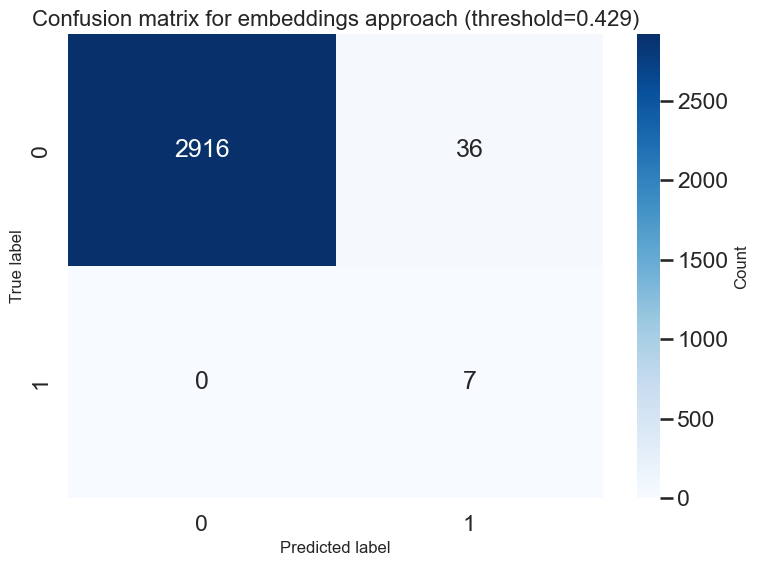


Confusion Matrix:
True Negatives (Non-AI correctly identified): 2916
False Positives (Non-AI incorrectly flagged): 36
False Negatives (AI courses missed): 0
True Positives (AI correctly identified): 7

Recall: 100.0%
Precision: 16.3%
False Positive Rate: 1.2%


In [92]:
courses_df = eval_df[eval_df['is_not_course'] == 0].copy()
courses_df['max_cos_similarity'] = courses_df['max_cos_similarity'].fillna(0)
courses_df['predicted_ai'] = (courses_df['max_cos_similarity'] >= threshold ).astype(int)

cm = confusion_matrix(courses_df['has_ai'], courses_df['predicted_ai'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['0', '1'], 
            yticklabels=['0', '1'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted label', fontsize=12)
plt.ylabel('True label', fontsize=12)
plt.title(f'Confusion matrix for embeddings approach (threshold={threshold})', fontsize=16)
plt.tight_layout()
plt.savefig('../figures/updated_confusion_matrix_embeddings.png', dpi=300, bbox_inches='tight')  # Save to current directory
plt.show()

print("\nConfusion Matrix:")
print(f"True Negatives (Non-AI correctly identified): {cm[0,0]}")
print(f"False Positives (Non-AI incorrectly flagged): {cm[0,1]}")
print(f"False Negatives (AI courses missed): {cm[1,0]}")
print(f"True Positives (AI correctly identified): {cm[1,1]}")

recall = cm[1,1] / (cm[1,0] + cm[1,1]) * 100
precision = cm[1,1] / (cm[0,1] + cm[1,1]) * 100
fpr = cm[0,1] / (cm[0,0] + cm[0,1]) * 100

print(f"\nRecall: {recall:.1f}%")
print(f"Precision: {precision:.1f}%")
print(f"False Positive Rate: {fpr:.1f}%")